<a href="https://colab.research.google.com/github/mzaib1012/Automated-Hardware-Reliability-Calculator/blob/main/notebooks/hardware_reliability_calculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📦 Hardware Bill of Materials (BOM) baseline generated and saved.

📊 SYSTEM HARDWARE RELIABILITY PROFILE AUDIT (@ 75.0 C)
  • Total Aggregated Failure Rate (FIT) : 447.39 failures/10^9 hours
  • System MTBF (Hours)                : 2,235,207 Hours
  • System MTBF (Expected Lifetime)    : 255.16 Years


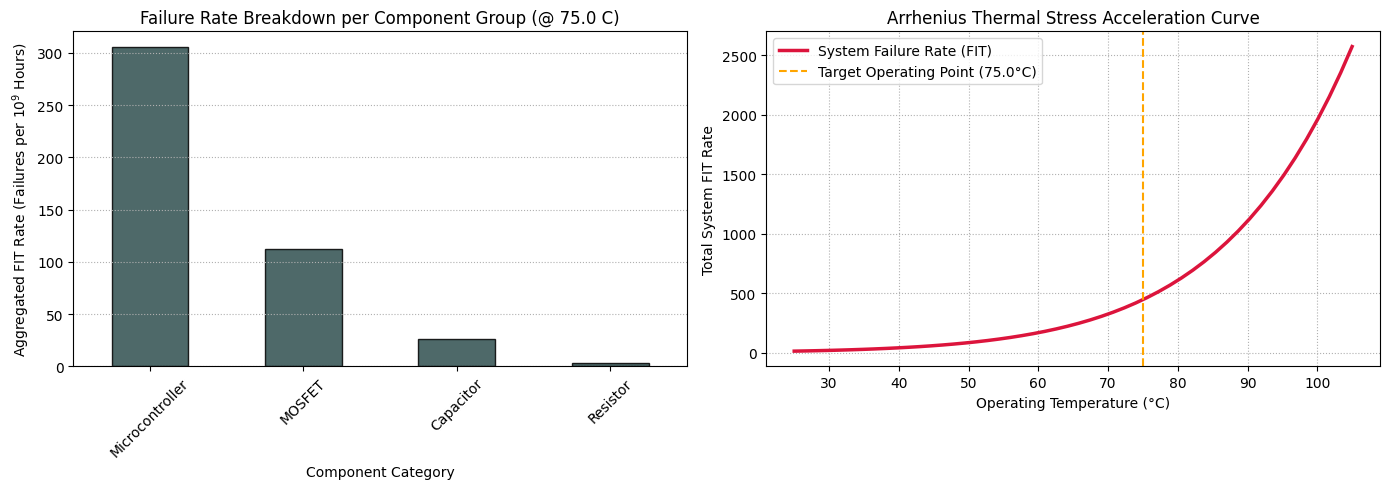

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Programmatically Generate a Sample Bill of Materials (BOM) ---
# Simulates a raw BOM export from electronic design automation tools (like Altium or KiCad)
bom_data = {
    'Component_Designator': ['U1', 'Q1', 'C1', 'C2', 'R1', 'R2', 'R3'],
    'Component_Type': ['Microcontroller', 'MOSFET', 'Capacitor', 'Capacitor', 'Resistor', 'Resistor', 'Resistor'],
    'Base_FIT': [15.0, 8.0, 2.0, 2.0, 0.5, 0.5, 0.5], # Base Failure in Time per unit at reference temperature
    'Activation_Energy_eV': [0.7, 0.6, 0.4, 0.4, 0.1, 0.1, 0.1], # Ea value for Arrhenius thermal stress acceleration
    'Quantity': [1, 1, 1, 1, 1, 1, 1]
}

df_bom = pd.DataFrame(bom_data)
df_bom.to_csv('system_bom.csv', index=False)
print("📦 Hardware Bill of Materials (BOM) baseline generated and saved.\n")

# --- 2. Telcordia SR-332 & Arrhenius Stress Acceleration Engine ---
def calculate_thermal_acceleration(T_operating, T_ref, Ea):
    """
    Computes the Arrhenius thermal acceleration factor (Pi_T) based on operating temperature.
    Formula: Pi_T = exp((Ea / k) * ((1 / T_ref) - (1 / T_operating)))
    """
    k = 8.617333262e-5  # Boltzmann constant in eV/K
    T_op_k = T_operating + 273.15  # Convert operational Temp to Kelvin
    T_ref_k = T_ref + 273.15      # Convert reference Temp to Kelvin

    pi_t = np.exp((Ea / k) * ((1 / T_ref_k) - (1 / T_op_k)))
    return pi_t

def run_reliability_audit(bom_path, operating_temp, environmental_factor=1.5):
    # Load and parse BOM
    df = pd.read_csv(bom_path)

    # Standard baseline parameters
    T_reference = 40.0  # Reference temperature for base FIT rates (Celsius)

    calculated_fits = []

    for idx, row in df.iterrows():
        # Calculate thermal acceleration multiplier for each specific component category
        pi_t = calculate_thermal_acceleration(operating_temp, T_reference, row['Activation_Energy_eV'])

        # Total component failure rate = Base_FIT * Pi_T * Pi_E (environmental stress factor)
        component_fit = row['Base_FIT'] * pi_t * environmental_factor * row['Quantity']
        calculated_fits.append(component_fit)

    df['Calculated_FIT'] = calculated_fits

    # Calculate aggregated parameters
    total_system_fit = df['Calculated_FIT'].sum()

    # MTBF (Hours) = 1e9 / Total_System_FIT
    system_mtbf_hours = 1e9 / total_system_fit
    system_mtbf_years = system_mtbf_hours / (24 * 365)

    return df, total_system_fit, system_mtbf_hours, system_mtbf_years

# --- 3. Execute Analysis over an Environmental Stress Range ---
operating_temperature_profile = 75.0  # Extreme stress operating temperature in Celsius
df_audit, total_fit, mtbf_h, mtbf_y = run_reliability_audit('system_bom.csv', operating_temperature_profile)

print("="*65)
print(f"📊 SYSTEM HARDWARE RELIABILITY PROFILE AUDIT (@ {operating_temperature_profile} C)")
print("="*65)
print(f"  • Total Aggregated Failure Rate (FIT) : {total_fit:.2f} failures/10^9 hours")
print(f"  • System MTBF (Hours)                : {mtbf_h:,.0f} Hours")
print(f"  • System MTBF (Expected Lifetime)    : {mtbf_y:.2f} Years")
print("="*65)

# Generate baseline temperature dependency curve for stress curves analysis
temp_range = np.linspace(25, 105, 50)
system_fit_curve = []
for t in temp_range:
    _, t_fit, _, _ = run_reliability_audit('system_bom.csv', t)
    system_fit_curve.append(t_fit)

# --- 4. Diagnostic Portfolio Plots ---
plt.figure(figsize=(14, 5))

# Plot 1: Failure rate analysis per component breakdown
plt.subplot(1, 2, 1)
df_grouped = df_audit.groupby('Component_Type')['Calculated_FIT'].sum().sort_values(ascending=False)
df_grouped.plot(kind='bar', color='darkslategray', edgecolor='black', alpha=0.85)
plt.title(f'Failure Rate Breakdown per Component Group (@ {operating_temperature_profile} C)')
plt.ylabel('Aggregated FIT Rate (Failures per $10^9$ Hours)')
plt.xlabel('Component Category')
plt.grid(axis='y', linestyle=':')
plt.xticks(rotation=45)

# Plot 2: Thermal degradation Arrhenius curve
plt.subplot(1, 2, 2)
plt.plot(temp_range, system_fit_curve, color='crimson', lw=2.5, label='System Failure Rate (FIT)')
plt.axvline(operating_temperature_profile, color='orange', linestyle='--',
            label=f'Target Operating Point ({operating_temperature_profile}°C)')
plt.title('Arrhenius Thermal Stress Acceleration Curve')
plt.ylabel('Total System FIT Rate')
plt.xlabel('Operating Temperature (°C)')
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.savefig('hardware_reliability_report.png', dpi=300)
plt.show()